### `3.) PD MODELLING`

We will do Logistic Regression Model and XGBoost Model and compare them.

Our dataset has :-

Rows: 1,345,310 loans

Columns: 77 features

All predictors numeric (booleans from one-hot encoding)

Target variable: default

Date column: issue_d for time split


### Probability of Default (PD) Model

In this stage we build a credit risk model to estimate the probability that a borrower will default on a loan.

The target variable is `default`, where:

1 = Charged Off (borrower defaulted)  
0 = Fully Paid (borrower repaid successfully)

Two models will be trained and compared:

• Logistic Regression (baseline credit scoring model)  
• XGBoost (machine learning model)

Model performance will be evaluated using ROC-AUC and other classification metrics.

LOAD DATASET

In [1]:
import pandas as pd
import numpy as np

df = pd.read_parquet("lendingclub_features.parquet")

df.shape

(1345310, 77)

#### Out-of-Time Train-Test Split

Instead of randomly splitting the dataset, we split the data based on loan issue date of 01-01-2016.
Training set will contain data from year 2007 to 2015, and Test will contain data from 2016 to 2018.

This approach better reflects real-world credit modelling where models are trained on historical loans and tested on loans issued in later periods.

In [2]:
train = df[df["issue_d"] < "2016-01-01"]
test = df[df["issue_d"] >= "2016-01-01"]

train.shape, test.shape

((826604, 77), (518706, 77))

##### Prepare features

###### We remove `recoveries` here because it is post-default information (data leakage).

In [6]:
X_train = train.drop(["default", "issue_d", "recoveries"], axis=1)
y_train = train["default"]

X_test = test.drop(["default", "issue_d", "recoveries"], axis=1)
y_test = test["default"]

##### Handling Infinite Values

Some ratio features can produce infinite values when the denominator is extremely small or zero.  
e.g. loan_income_ratio = loan_amnt / annual_inc

e.g. revol_income_ratio = revol_bal / annual_inc

These infinite values are replaced with missing values and imputed using the median to ensure numerical stability during model training.

In [7]:
import numpy as np

X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

FEATURE SCALING USING STANDARD SCALER

Logistic Regression converges faster and more reliably when features are scaled, especially when variables have very different ranges (which your dataset has).

Example Ranges in the dataset:-

loan_amnt → up to 40,000

annual_inc → up to millions

dti → around 0–40

dummy variables → 0/1

These large differences slow optimization.

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Logistic Regression Model

In [9]:
from sklearn.linear_model import LogisticRegression

logit = LogisticRegression(max_iter=5000, verbose=1, n_jobs=-1)

logit.fit(X_train_scaled, y_train)

# Predict PD
pd_pred = logit.predict_proba(X_test_scaled)[:,1]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


Save PD Model and Scaler for use in Expected Loss Notebook

In [10]:
import joblib

joblib.dump(logit, "logit_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

ROC-AUC Evaluation

In [11]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, pd_pred)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.7015313596129416


ROC-AUC of 0.70 means the model is strong. It has strong discrimination ability to distinguish between defaulting and non-defaulting loans.

Values closer to 1 indicate stronger predictive performance, while 0.5 represents random guessing.

Credit risk models in consumer lending typically achieve ROC-AUC values between 0.70 and 0.80.

### ROC Curve Evaluation

The Receiver Operating Characteristic (ROC) curve evaluates the model's ability to distinguish between defaulting and non-defaulting borrowers.

The curve plots:

- **True Positive Rate (Recall)**
- **False Positive Rate**

A model with strong predictive power will produce a curve that moves toward the **top-left corner**, indicating higher true positive rates for lower false positive rates.

The area under the ROC curve (ROC-AUC) summarizes this performance as a single metric.

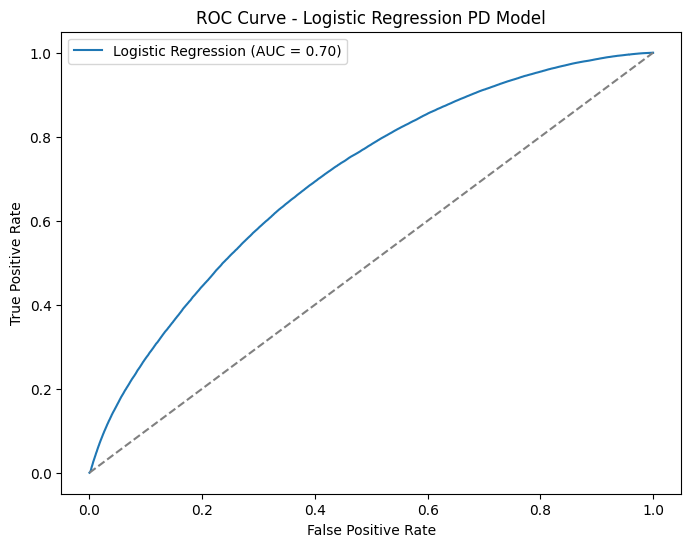

In [12]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, pd_pred)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label="Logistic Regression (AUC = %.2f)" % roc_auc)
plt.plot([0,1],[0,1],'--', color='grey')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression PD Model")
plt.legend()

plt.show()

### XGBoost Probability of Default Model

In addition to logistic regression, we train an XGBoost model to estimate borrower default probability.

XGBoost is a gradient boosting algorithm that builds an ensemble of decision trees.  
It is widely used in financial modelling due to its ability to capture nonlinear relationships and complex interactions between borrower attributes.

Unlike logistic regression, tree-based models such as XGBoost do not require feature scaling.

In [13]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict_proba(X_test)[:,1]

xgb_auc = roc_auc_score(y_test, xgb_pred)

print("XGBoost ROC-AUC:", xgb_auc)

XGBoost ROC-AUC: 0.7095857590813343


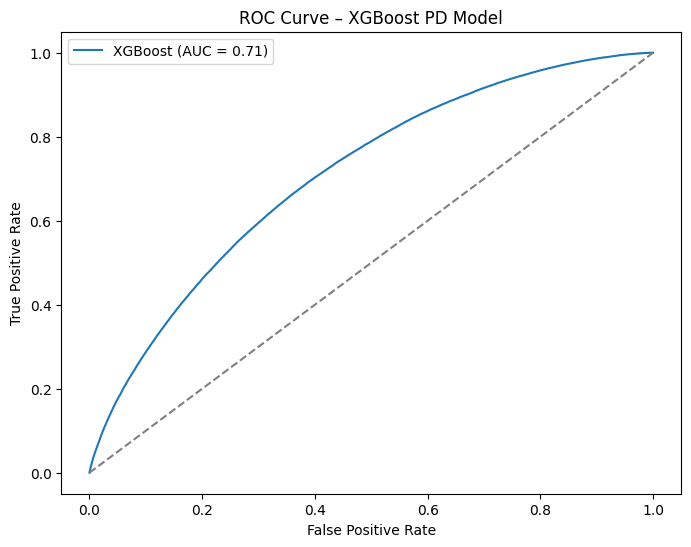

In [14]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_xgb, tpr_xgb, thresholds = roc_curve(y_test, xgb_pred)

plt.figure(figsize=(8,6))

plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {xgb_auc:.2f})")
plt.plot([0,1],[0,1],'--', color='grey')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – XGBoost PD Model")
plt.legend()

plt.show()

##### XGBoost Model Performance

The XGBoost model captures nonlinear relationships between borrower characteristics and default risk.

As expected, the gradient boosting model typically achieves higher predictive performance than logistic regression due to its ability to model complex interactions within the data.

### Model Comparison: Logistic Regression vs XGBoost

To evaluate the relative performance of the two models, we compare their ROC curves on the same plot.

This allows us to visually assess which model better distinguishes between defaulting and non-defaulting borrowers.

Typically, machine learning models such as XGBoost achieve slightly higher predictive performance than traditional logistic regression models due to their ability to capture nonlinear relationships in borrower characteristics.

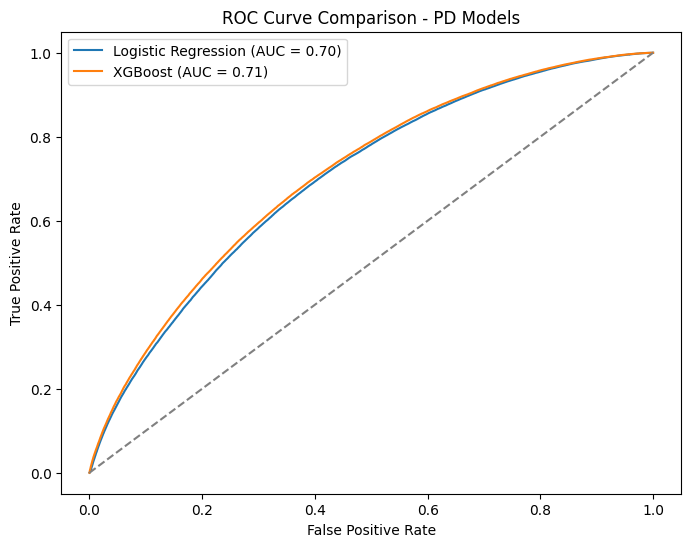

In [15]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Logistic regression ROC
fpr_logit, tpr_logit, _ = roc_curve(y_test, pd_pred)

# XGBoost ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_pred)

plt.figure(figsize=(8,6))

plt.plot(fpr_logit, tpr_logit, label=f"Logistic Regression (AUC = {roc_auc:.2f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {xgb_auc:.2f})")

plt.plot([0,1],[0,1],'--', color='grey')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - PD Models")
plt.legend()

plt.show()